# IVS Cargo Flow Analysis & Fairway Network Routing

This notebook serves as a comprehensive guide for using the integrated FIS/EURIS fairway graph. We demonstrate how to:
1. **Load Logistics Data:** Fetch IVS weekmonitor cargo data from the Rijkswaterstaat open data portal.
2. **Geographical Mapping:** Use the Zenodo Geocoded UN/LOCODE dataset as the primary source for location coordinates.
3. **Network Integration:** Map coordinates to the nearest topological `sectionjunction` nodes in our fairway graph.
4. **Smart Routing:** Compute shortest paths while penalizing sea-based fairways (e.g., the North Sea) to keep cargo flows on inland waterways.
5. **Spatial Aggregation:** Collapse individual routes into a single network map showing cargo intensity per section.

In [1]:
import pathlib
import zipfile
import io
import requests
import pickle
import itertools
import logging
from collections import defaultdict

import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import contextily as cx
import numpy as np
from tqdm.auto import tqdm
from scipy.spatial import cKDTree

# Set up logging for high-level information
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

/Users/baart_f/src/fis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Acquisition

We fetch a pinned version of the IVS (Inland Vessel System) weekmonitor data from March 2026. This dataset contains cargo origin/destination pairs identified by 5-character UN/LOCODEs.

In [2]:
ivs_url = "https://downloads.rijkswaterstaatdata.nl/scheepvaart/goederenvervoer/archief/IVS_weekmonitor_31MAR2026_20260401_051939.zip"

logger.info(f"Fetching IVS data from {ivs_url}...")
r = requests.get(ivs_url, timeout=30)
r.raise_for_status()  # Fail fast if the URL is inaccessible

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        ivs_df = pd.read_csv(f, sep=";")

logger.info(f"Loaded {len(ivs_df)} records from {csv_filename}.")
ivs_df.head()

INFO: Fetching IVS data from https://downloads.rijkswaterstaatdata.nl/scheepvaart/goederenvervoer/archief/IVS_weekmonitor_31MAR2026_20260401_051939.zip...


INFO: Loaded 55646 records from IVS_weekmonitor_31MAR2026.csv.


,Jaarmaand,Jaar,Maand,Weeknr,v05_06_Begindt_evenement_iso,v05_06_Begindt_evenement,UNLO_herkomst,UNLO_bestemming,v15_1_Scheepstype_RWS,SK_CODE,v18_Laadvermogen,v28_Beladingscode,v38_Vervoerd_gewicht,v30_4_Containers_TEU_S,nstr_nw,nst2007_nw
0,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEANR,DEFRA,2,M8,2660,7,1303000.0,0,3.0,7.2
1,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEANR,NLAMS,2,M8,3550,7,1030000.0,0,3.0,8.5
2,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,NLLEY,NLUTC,1,M8,3230,7,514125.0,65,9.0,19.2
3,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,NLAMS,FRSXB,2,M9,3500,7,2122000.0,0,3.0,7.2
4,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEGNE,BEANR,2,M10,5220,7,2704000.0,0,8.0,8.2


### 1.1 Load Zenodo Reference Data

Mapping raw UN/LOCODEs directly to network nodes is often imprecise (e.g., Rotterdam has 300+ nodes). We use the **Deltares Zenodo Geocoded UN/LOCODE dataset** to find an authoritative centroid for each port area.

In [3]:
zenodo_url = (
    "https://zenodo.org/records/11191511/files/unlo-geocoded-v0.1.gpkg?download=1"
)
zenodo_local = pathlib.Path("unlo-geocoded-v0.1.gpkg")

if not zenodo_local.exists():
    logger.info(f"Downloading Zenodo reference data to {zenodo_local}...")
    r = requests.get(zenodo_url, timeout=60)
    r.raise_for_status()
    zenodo_local.write_bytes(r.content)

zenodo_gdf = gpd.read_file(zenodo_local)
logger.info(f"Loaded {len(zenodo_gdf)} geocoded reference locations.")

INFO: Loaded 116432 geocoded reference locations.


## 2. Prepare the Fairway Network

The graph is a `networkx` object where nodes are topological junctions. We convert it to a GeoDataFrame for spatial operations. Note that we strictly use Shapely geometry objects.

In [4]:
graph_path = pathlib.Path("../output/merged-graph/graph.pickle")
with graph_path.open("rb") as f:
    graph = pickle.load(f)

# Convert graph nodes to a GeoDataFrame
nodes_gdf = gpd.GeoDataFrame(
    graph.nodes.values(), index=graph.nodes.keys(), geometry="geometry", crs="EPSG:4326"
)
logger.info(f"Loaded network with {len(nodes_gdf)} nodes.")

# Build a spatial index (KDTree) for fast nearest-neighbor lookups
nodes_coords = np.array(list(zip(nodes_gdf.geometry.x, nodes_gdf.geometry.y)))
tree = cKDTree(nodes_coords)

INFO: Loaded network with 7089 nodes.


### 2.1 Routing Constraints: Sea Avoidance

Inland vessels should stay on inland fairways. We define a weight function that heavily penalizes fairways marked as part of the North Sea ("Noordzee").

In [5]:
def length_avoid_sea(u, v, d):
    """
    Weight function for Dijkstra's algorithm.
    If the section belongs to the North Sea, the weight is effectively infinite.
    """
    length = d.get("length_m", 1.0)
    water_name = str(d.get("water_name", ""))

    if water_name == "Noordzee":
        return length * 100000000  # 100,000 km penalty

    return length

## 3. Identify High-Volume Flows

We filter for domestic Dutch routes and aggregate by transported weight.

In [6]:
# Domestic routes
nl_mask = ivs_df["UNLO_herkomst"].str.startswith("NL", na=False) & ivs_df[
    "UNLO_bestemming"
].str.startswith("NL", na=False)
ivs_nl = ivs_df[nl_mask].copy()

od_pairs = (
    ivs_nl.groupby(["UNLO_herkomst", "UNLO_bestemming"])["v38_Vervoerd_gewicht"]
    .sum()
    .reset_index()
)
top_100_od = od_pairs.sort_values(by="v38_Vervoerd_gewicht", ascending=False).head(100)
top_100_od.head(10)

,UNLO_herkomst,UNLO_bestemming,v38_Vervoerd_gewicht
3711,NLRTM,NLAMS,1.613743e+09
305,NLAMS,NLRTM,5.287459e+08
3840,NLRTM,NLRTM,4.868439e+08
3860,NLRTM,NLVLI,2.207039e+08
4525,NLVLI,NLAMS,2.200845e+08
4567,NLVLI,NLRTM,1.995461e+08
3810,NLRTM,NLMOE,1.896690e+08
226,NLAMS,NLGOU,1.536277e+08
176,NLAMS,NLAMS,1.201441e+08
3852,NLRTM,NLTNZ,1.151215e+08


## 4. Batch Routing & Flow Aggregation

For each OD pair, we:
1. Find the port coordinate in Zenodo.
2. Locate the nearest graph node.
3. Compute the shortest path.
4. Accumulate cargo weight onto the specific edges (fairway sections) used.

In [7]:
def get_network_node_via_zenodo(unlocode):
    """Finds the closest network node to the Zenodo coordinate for a UN/LOCODE."""
    # Split country and location
    cc, lc = unlocode[:2], unlocode[2:]
    ref = zenodo_gdf[
        (zenodo_gdf["country_code"] == cc) & (zenodo_gdf["location_code"] == lc)
    ]
    if ref.empty:
        return None

    # Query KDTree for nearest network node
    p = ref.geometry.iloc[0]
    dist, idx = tree.query((p.x, p.y))
    return nodes_gdf.index[idx]


edge_cargo = defaultdict(float)
edge_info = {}

for _, row in tqdm(
    top_100_od.iterrows(), total=len(top_100_od), desc="Processing flows"
):
    u_node = get_network_node_via_zenodo(row["UNLO_herkomst"])
    v_node = get_network_node_via_zenodo(row["UNLO_bestemming"])

    if u_node and v_node:
        try:
            route = nx.shortest_path(graph, u_node, v_node, weight=length_avoid_sea)
            for u, v in itertools.pairwise(route):
                # Undirected graph: normalize edge key
                edge_key = tuple(sorted((u, v)))
                edge_cargo[edge_key] += row["v38_Vervoerd_gewicht"]
                if edge_key not in edge_info:
                    edge_info[edge_key] = graph.edges[u, v]
        except nx.NetworkXNoPath:
            continue

# Reconstruct GeoDataFrame of used edges
intensity_data = []
for edge_key, weight in edge_cargo.items():
    data = edge_info[edge_key]
    intensity_data.append({"geometry": data["geometry"], "cargo_weight": weight})

intensity_gdf = gpd.GeoDataFrame(intensity_data, geometry="geometry", crs="EPSG:4326")

Processing flows:   0%|                                                                              | 0/100 [00:00<?, ?it/s]

Processing flows:  26%|█████████████████▋                                                  | 26/100 [00:00<00:00, 256.19it/s]

Processing flows:  52%|███████████████████████████████████▎                                | 52/100 [00:00<00:00, 254.93it/s]

Processing flows:  80%|██████████████████████████████████████████████████████▍             | 80/100 [00:00<00:00, 265.11it/s]

Processing flows: 100%|███████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 264.36it/s]

## 5. Visualizing Cargo Intensity

The final map displays the network segments scaled by the total volume of cargo they support.

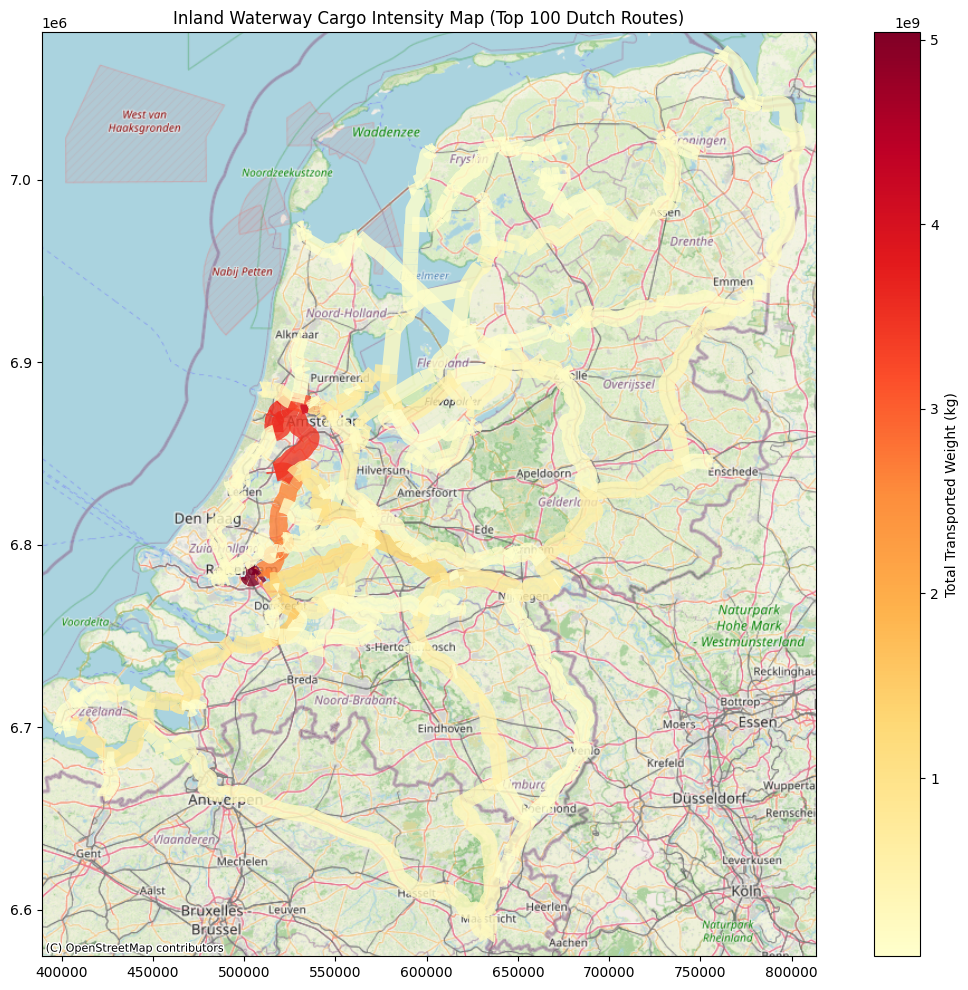

In [8]:
viz_gdf = intensity_gdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(15, 12))

# Use log scale for line width
max_w = viz_gdf["cargo_weight"].max()
viz_gdf["linewidth"] = 1 + 12 * (np.log1p(viz_gdf["cargo_weight"]) / np.log1p(max_w))

viz_gdf.plot(
    ax=ax,
    column="cargo_weight",
    cmap="YlOrRd",
    linewidth=viz_gdf["linewidth"],
    alpha=0.8,
    legend=True,
    legend_kwds={"label": "Total Transported Weight (kg)"},
)

# Set display extent to the computed routes with padding
b = viz_gdf.total_bounds
ax.set_xlim(b[0] - 10000, b[2] + 10000)
ax.set_ylim(b[1] - 10000, b[3] + 10000)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title("Inland Waterway Cargo Intensity Map (Top 100 Dutch Routes)")
plt.show()